In [138]:
import pandas as pd 
import json
data = pd.read_csv(r"C:\Users\Ittikorn\OneDrive\Desktop\Ai\Machinelearning\ssswork\Dataset\tmdb_5000_movies.csv")

In [139]:
from sklearn.feature_extraction.text import TfidfVectorizer
from sklearn.metrics.pairwise import cosine_similarity

In [140]:
data.head()

,budget,genres,homepage,id,keywords,original_language,original_title,overview,popularity,production_companies,production_countries,release_date,revenue,runtime,spoken_languages,status,tagline,title,vote_average,vote_count
0,237000000,"[{""id"": 28, ""name"": ""Action""}, {""id"": 12, ""nam...",http://www.avatarmovie.com/,19995,"[{""id"": 1463, ""name"": ""culture clash""}, {""id"":...",en,Avatar,"In the 22nd century, a paraplegic Marine is di...",150.437577,"[{""name"": ""Ingenious Film Partners"", ""id"": 289...","[{""iso_3166_1"": ""US"", ""name"": ""United States o...",2009-12-10,2787965087,162.0,"[{""iso_639_1"": ""en"", ""name"": ""English""}, {""iso...",Released,Enter the World of Pandora.,Avatar,7.2,11800
1,300000000,"[{""id"": 12, ""name"": ""Adventure""}, {""id"": 14, ""...",http://disney.go.com/disneypictures/pirates/,285,"[{""id"": 270, ""name"": ""ocean""}, {""id"": 726, ""na...",en,Pirates of the Caribbean: At World's End,"Captain Barbossa, long believed to be dead, ha...",139.082615,"[{""name"": ""Walt Disney Pictures"", ""id"": 2}, {""...","[{""iso_3166_1"": ""US"", ""name"": ""United States o...",2007-05-19,961000000,169.0,"[{""iso_639_1"": ""en"", ""name"": ""English""}]",Released,"At the end of the world, the adventure begins.",Pirates of the Caribbean: At World's End,6.9,4500
2,245000000,"[{""id"": 28, ""name"": ""Action""}, {""id"": 12, ""nam...",http://www.sonypictures.com/movies/spectre/,206647,"[{""id"": 470, ""name"": ""spy""}, {""id"": 818, ""name...",en,Spectre,A cryptic message from Bond’s past sends him o...,107.376788,"[{""name"": ""Columbia Pictures"", ""id"": 5}, {""nam...","[{""iso_3166_1"": ""GB"", ""name"": ""United Kingdom""...",2015-10-26,880674609,148.0,"[{""iso_639_1"": ""fr"", ""name"": ""Fran\u00e7ais""},...",Released,A Plan No One Escapes,Spectre,6.3,4466
3,250000000,"[{""id"": 28, ""name"": ""Action""}, {""id"": 80, ""nam...",http://www.thedarkknightrises.com/,49026,"[{""id"": 849, ""name"": ""dc comics""}, {""id"": 853,...",en,The Dark Knight Rises,Following the death of District Attorney Harve...,112.312950,"[{""name"": ""Legendary Pictures"", ""id"": 923}, {""...","[{""iso_3166_1"": ""US"", ""name"": ""United States o...",2012-07-16,1084939099,165.0,"[{""iso_639_1"": ""en"", ""name"": ""English""}]",Released,The Legend Ends,The Dark Knight Rises,7.6,9106
4,260000000,"[{""id"": 28, ""name"": ""Action""}, {""id"": 12, ""nam...",http://movies.disney.com/john-carter,49529,"[{""id"": 818, ""name"": ""based on novel""}, {""id"":...",en,John Carter,"John Carter is a war-weary, former military ca...",43.926995,"[{""name"": ""Walt Disney Pictures"", ""id"": 2}]","[{""iso_3166_1"": ""US"", ""name"": ""United States o...",2012-03-07,284139100,132.0,"[{""iso_639_1"": ""en"", ""name"": ""English""}]",Released,"Lost in our world, found in another.",John Carter,6.1,2124


In [141]:
x = data.iloc[0] # เลือกข้อมูลด้วยตำแหน่งลำดับ
x

budget                                                          237000000
genres                  [{"id": 28, "name": "Action"}, {"id": 12, "nam...
homepage                                      http://www.avatarmovie.com/
id                                                                  19995
keywords                [{"id": 1463, "name": "culture clash"}, {"id":...
original_language                                                      en
original_title                                                     Avatar
overview                In the 22nd century, a paraplegic Marine is di...
popularity                                                     150.437577
production_companies    [{"name": "Ingenious Film Partners", "id": 289...
production_countries    [{"iso_3166_1": "US", "name": "United States o...
release_date                                                   2009-12-10
revenue                                                        2787965087
runtime                               

In [142]:
x['genres']

'[{"id": 28, "name": "Action"}, {"id": 12, "name": "Adventure"}, {"id": 14, "name": "Fantasy"}, {"id": 878, "name": "Science Fiction"}]'

In [143]:
x ['keywords']

'[{"id": 1463, "name": "culture clash"}, {"id": 2964, "name": "future"}, {"id": 3386, "name": "space war"}, {"id": 3388, "name": "space colony"}, {"id": 3679, "name": "society"}, {"id": 3801, "name": "space travel"}, {"id": 9685, "name": "futuristic"}, {"id": 9840, "name": "romance"}, {"id": 9882, "name": "space"}, {"id": 9951, "name": "alien"}, {"id": 10148, "name": "tribe"}, {"id": 10158, "name": "alien planet"}, {"id": 10987, "name": "cgi"}, {"id": 11399, "name": "marine"}, {"id": 13065, "name": "soldier"}, {"id": 14643, "name": "battle"}, {"id": 14720, "name": "love affair"}, {"id": 165431, "name": "anti war"}, {"id": 193554, "name": "power relations"}, {"id": 206690, "name": "mind and soul"}, {"id": 209714, "name": "3d"}]'

In [144]:
j = json.loads(x['genres'])  # ใช้ อ่านข้อมูล JSON (ไฟล์text) จากไฟล์ แล้วแปลงเป็นข้อมูลชนิด Python เช่น dictionary หรือ list
j

[{'id': 28, 'name': 'Action'},
 {'id': 12, 'name': 'Adventure'},
 {'id': 14, 'name': 'Fantasy'},
 {'id': 878, 'name': 'Science Fiction'}]

In [145]:
# ทำให้ เป็นtoken เดียวกัน คือ จาก j เราต้องการข้างใน name เราให้jj[name].split แยกเป็นแต่ละคำ แล้วก็ไม่เอาระยะห่างแล้วทำทั้งหมดตั้งแต่ jj ใน j
# .join คือเอาคำมาต่อกัน เรา split เพื่อให้คำที่เว้นวรรค แนกไปคนละคำแล้วค่อยเอิามาต่อกัน ต่อจากนั้นก็เอาคำทั้งหมดมาต่อกัน
(''.join(''.join(jj['name'].split())for jj in j)) 

'ActionAdventureFantasyScienceFiction'

In [146]:
def genres_and_keyword_to_string(row) :
    genres = json.loads(row['genres']) 
    genres = ''.join(''.join(j['name'].split())for j in genres)
    
    keywords = json.loads(row['keywords'])
    keywords = ''.join(''.join(j['name'].split())for j in keywords)
    return "%s %s" % (genres,keywords)

In [147]:
#สร้าง Column ใหม่
data['string'] = data.apply(genres_and_keyword_to_string ,axis=1)
data['string']

0       ActionAdventureFantasyScienceFiction culturecl...
1       AdventureFantasyAction oceandrugabuseexoticisl...
2       ActionAdventureCrime spybasedonnovelsecretagen...
3       ActionCrimeDramaThriller dccomicscrimefightert...
4       ActionAdventureScienceFiction basedonnovelmars...
                              ...                        
4798    ActionCrimeThriller unitedstates–mexicobarrier...
4799                                       ComedyRomance 
4800    ComedyDramaRomanceTVMovie dateloveatfirstsight...
4801                                                     
4802         Documentary obsessioncamcordercrushdreamgirl
Name: string, Length: 4803, dtype: str

In [148]:
# make TFVectorizer
vectorizer  = TfidfVectorizer()
x = vectorizer.fit_transform(data['string'])
x

<Compressed Sparse Row sparse matrix of dtype 'float64'
	with 9925 stored elements and shape (4803, 6026)>

In [149]:
#Mapping  Entity to position
indxmap = pd.Series(data.index,index=data['title'])
indxmap

title
Avatar                                         0
Pirates of the Caribbean: At World's End       1
Spectre                                        2
The Dark Knight Rises                          3
John Carter                                    4
                                            ... 
El Mariachi                                 4798
Newlyweds                                   4799
Signed, Sealed, Delivered                   4800
Shanghai Calling                            4801
My Date with Drew                           4802
Length: 4803, dtype: int64

In [150]:
# Use searching movie
idx = indxmap['Scream 3']
idx

1164

In [151]:
# query = หนังที่เราค้นหา
query  = x[idx]
# แปลง คำที่เราหาเป็น Vector
query.toarray()

array([[0., 0., 0., ..., 0., 0., 0.]])

In [152]:
#Compute Similarity from  query vector and x vector  
score = cosine_similarity(query,x)
score

array([[0., 0., 0., ..., 0., 0., 0.]])

In [153]:
# convbert to 1D array
score = score.flatten()
score

array([0., 0., 0., ..., 0., 0., 0.])

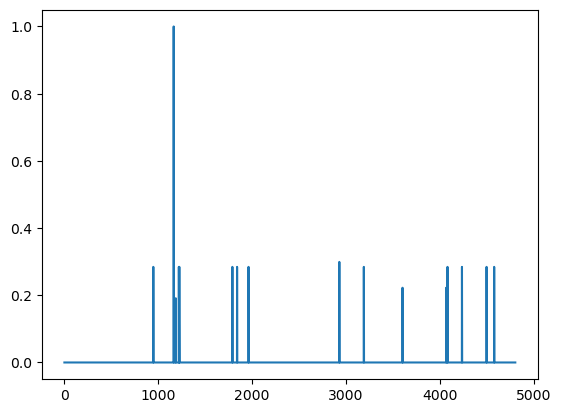

In [154]:
import matplotlib.pyplot as plt 
plt.plot(score)

In [156]:
# Argsortใช่บอกจากน้อยไปมาก เราต้องการ score ให้จากมากที่สุดไปน้อยที่สุด เลยติดลบ
rank = (-score).argsort()
rank

array([1164, 2928, 4577, ..., 1599, 1597, 4802], dtype=int64)

In [158]:
# Top 5 movie
recommend_idx = rank[0:6]
recommend_idx

array([1164, 2928, 4577,  947, 3189, 1839], dtype=int64)

In [ ]:
# เลือก ข้อมูลจากDataframe เป็น 
data['title'].iloc[recommend_idx]

1164               Scream 3
2928                 Saw VI
4577    Paranormal Activity
947             Silent Hill
3189            The Wailing
1839    Final Destination 3
Name: title, dtype: str